<a href="https://colab.research.google.com/github/developeralamin/python-problem-solve/blob/master/ML%20model%20to%20prediction%20employability.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Shape: (50000, 23)
   Age  Gender University_Year                   Major  Attendance_Percentage  \
0   22    Male       Sophomore        Computer Science                     86   
1   20  Female        Freshman        Computer Science                     64   
2   23    Male          Senior  Information Technology                     75   
3   23  Female          Senior  Information Technology                     80   
4   23  Female          Senior    Software Engineering                     73   

   Study_Hours_Per_Week  CGPA Academic_Performance  Programming_Skill  \
0                    21  3.28                 Good                  9   
1                    18  2.53                 Poor                  6   
2                    19  2.83              Average                  8   
3                    19  2.80              Average                  5   


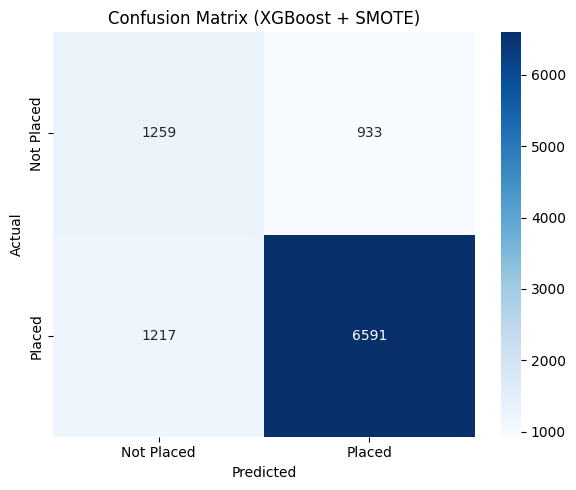


Calculating Permutation Importances...

Top 15 Important Features:
                  Feature  Importance
10         Certifications    0.002772
23     Skills_per_Project    0.001736
3                   Major    0.000543
0                     Age    0.000471
2         University_Year    0.000262
11             Hackathons    0.000225
1                  Gender    0.000155
15       LinkedIn_Profile    0.000038
12         GitHub_Profile   -0.000116
5    Study_Hours_Per_Week   -0.000167
20    English_Proficiency   -0.000204
18               Teamwork   -0.000259
7    Academic_Performance   -0.000397
16           Resume_Score   -0.000433
14  Leadership_Experience   -0.000602


/tmp/ipykernel_759/1775067636.py:183: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance_df.head(15), x='Importance', y='Feature', palette='viridis')


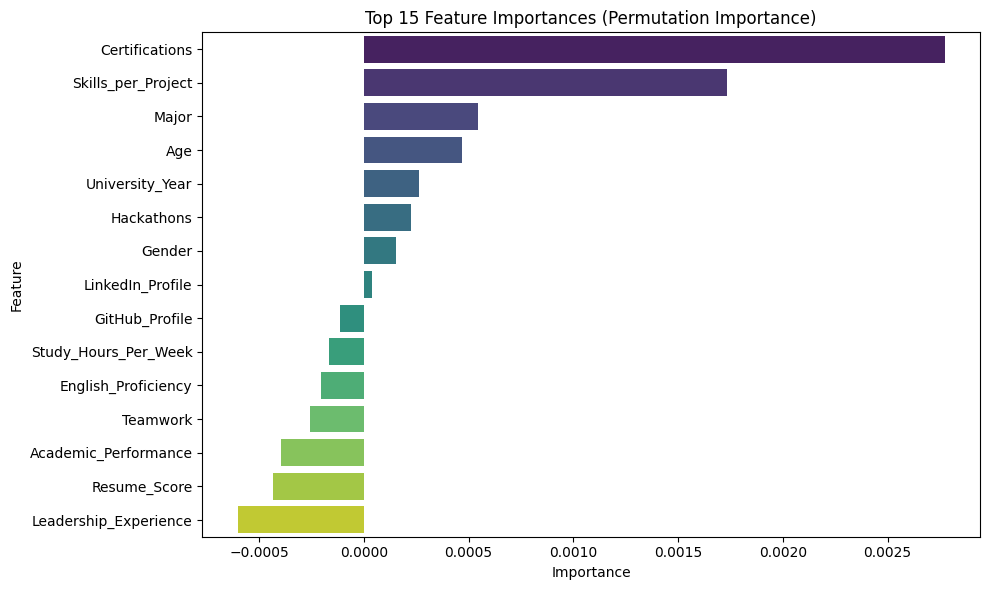


All results, metrics, predictions CSV, and trained model saved successfully at: /content/drive/MyDrive/Thesis_WUB/CSE_Thesis/


In [ ]:
# =========================
# 1. Setup
# =========================
from google.colab import drive
drive.mount('/content/drive')

import os
import time
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.inspection import permutation_importance

# Advanced Handling Libraries
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from xgboost import XGBClassifier

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Output Directory Setup
output_dir = '/content/drive/MyDrive/Thesis_WUB/CSE_Thesis/'
os.makedirs(output_dir, exist_ok=True)

# =========================
# 2. Load data
# =========================
file_path = os.path.join(output_dir, 'student_career_success_dataset_cleaned.csv')
df = pd.read_csv(file_path)

print("Shape:", df.shape)
print(df.head())

# =========================
# 3. Cleaning & String Formatting
# =========================
df = df.drop_duplicates()

# object print
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = df[col].astype(str).str.strip()

target_col = 'Placement_Status'
assert target_col in df.columns, f"{target_col} not found in dataset"

# =========================
# 4. Feature Engineering
# =========================
if {'Interview_Score', 'Internships'}.issubset(df.columns):
    df['Overall_Preparedness_Index'] = (df['Interview_Score'] * 0.7) + (df['Internships'] * 0.3)

if {'Programming_Skill', 'Projects_Completed'}.issubset(df.columns):
    df['Skills_per_Project'] = df['Programming_Skill'] / (df['Projects_Completed'] + 1)

# =========================
# 5. Split X and y
# =========================
X = df.drop(columns=[target_col])
y = df[target_col]

label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y)
print("Target classes:", list(label_encoder.classes_)) # [Not Placed: 0, Placed: 1]

# =========================
# 6. Feature types
# =========================
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object', 'bool']).columns.tolist()

print("\nNumeric features:", len(numeric_features))
print("Categorical features:", len(categorical_features))

# =========================
# 7. Preprocessing Pipelines
# =========================
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ],
    remainder='drop'
)

# =========================
# 8. Train-Test Split
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

# =========================
# 9. Advanced Pipeline (SMOTE + XGBoost)
# =========================
scale_pos_weight = (len(y_train) - sum(y_train)) / sum(y_train)

improved_pipeline = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=RANDOM_STATE)),
    ('model', XGBClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=6,
        scale_pos_weight=scale_pos_weight,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

print("\n--- Training Improved Model (XGBoost + SMOTE) ---")
start = time.time()
improved_pipeline.fit(X_train, y_train)
elapsed = time.time() - start
print(f"Training completed in {elapsed:.2f} seconds.")

# =========================
# 10. Evaluation with Custom Threshold (0.35)
# =========================
y_probs = improved_pipeline.predict_proba(X_test)[:, 1]
custom_threshold = 0.35
y_pred = (y_probs >= custom_threshold).astype(int)

final_metrics = {
    'Accuracy': accuracy_score(y_test, y_pred),
    'Precision': precision_score(y_test, y_pred, average='weighted', zero_division=0),
    'Recall': recall_score(y_test, y_pred, average='weighted', zero_division=0),
    'F1': f1_score(y_test, y_pred, average='weighted', zero_division=0)
}

print("\n--- Final Model Evaluation (Custom Threshold 0.35) ---")
print(final_metrics)
print("\nClassification Report:\n", classification_report(y_test, y_pred, target_names=label_encoder.classes_))

# Confusion Matrix Visualisation
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title('Confusion Matrix (XGBoost + SMOTE)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'improved_confusion_matrix.png'))
plt.show()

# =========================
# 11. Permutation Importance
# =========================
print("\nCalculating Permutation Importances...")
perm = permutation_importance(improved_pipeline, X_test, y_test, n_repeats=5, random_state=RANDOM_STATE, scoring='f1_weighted', n_jobs=-1)

importance_df = pd.DataFrame({
    'Feature': X_test.columns,
    'Importance': perm.importances_mean
}).sort_values(by='Importance', ascending=False)

print("\nTop 15 Important Features:")
print(importance_df.head(15))
importance_df.to_csv(os.path.join(output_dir, 'improved_feature_importance.csv'), index=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df.head(15), x='Importance', y='Feature', palette='viridis')
plt.title('Top 15 Feature Importances (Permutation Importance)')
plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'improved_feature_importance.png'))
plt.show()

# =========================
# 12. Save Predictions CSV & Artifacts
# =========================
output_df = X_test.copy()
output_df['Actual_Status'] = label_encoder.inverse_transform(y_test)
output_df['Predicted_Status'] = label_encoder.inverse_transform(y_pred)
output_df['Placement_Probability'] = y_probs

predictions_csv_path = os.path.join(output_dir, 'improved_placement_predictions.csv')
output_df.to_csv(predictions_csv_path, index=False)

with open(os.path.join(output_dir, 'improved_final_metrics.json'), 'w') as f:
    json.dump(final_metrics, f, indent=2)

joblib.dump(improved_pipeline, os.path.join(output_dir, 'best_employability_pipeline.pkl'))
joblib.dump(label_encoder, os.path.join(output_dir, 'label_encoder.pkl'))

print(f"\nAll results, metrics, predictions CSV, and trained model saved successfully at: {output_dir}")